In [43]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords, opinion_lexicon
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

In [44]:
listingsDF = pd.read_csv("listings.csv", dtype={"id": "string"}, low_memory=False)
listingsDF["id"] = listingsDF["id"].str.strip()
display(listingsDF.head())

,id,listing_url,name,description,host_id,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_neighbourhood,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,availability_30,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,61878,https://www.airbnb.com/rooms/61878,MODERN LIVING AND FURNISHINGS,"Close to downtown and Uptown. Fast and convenient to highway, grocery shops, dinner, clubbing and much more. Very m...",300211,Sasha,11/26/10,within an hour,100%,100%,Oak Lawn,3,District 2,32.817,-96.820,Entire condo,Entire home/apt,3,1.000,1 bath,1.000,2.000,"[""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""Self check-in"", ""Heating"", ""Shampoo"", ""Shared pool"", ""Dryer...",$85.00,0,307,55,12/29/10,12/30/23,4.700,4.790,4.620,4.850,4.920,4.750,4.770,0.340
1,270936,https://www.airbnb.com/rooms/270936,1BR 1BA Oaklawn Condo Close to Downtown & Uptown,"Perfect for business or pleasure. Completely remodeled, Centrally located in Oaklawn, near downtown, medical center,...",1417982,Robert,11/17/11,within a day,100%,100%,Oak Lawn,3,District 14,32.814,-96.815,Entire condo,Entire home/apt,2,1.000,1 bath,1.000,1.000,"[""Patio or balcony"", ""Essentials"", ""Smoke alarm"", ""Private entrance"", ""Self check-in"", ""Dishwasher"", ""Shampoo"", ""Sha...",$65.00,23,82,44,7/1/15,12/4/21,4.930,4.950,4.890,4.910,4.950,4.910,4.930,0.400
2,795703,https://www.airbnb.com/rooms/795703,Amazing location walk to Downtown Dallas,***** Over 30% Discounts for stays over 30 days or more ******<br />You can't beat the location of this beautiful p...,4191322,Michelle,11/19/12,within an hour,100%,90%,Oak Lawn,4,District 14,32.803,-96.810,Entire condo,Entire home/apt,2,1.000,1 bath,1.000,1.000,"[""Board games"", ""Essentials"", ""Smoke alarm"", ""Stainless steel electric stove"", ""Self check-in"", ""Building staff"", ""D...",$243.00,0,230,70,2/1/13,9/25/22,4.840,4.910,4.970,4.910,4.970,4.910,4.750,0.510
3,826118,https://www.airbnb.com/rooms/826118,Far North Dallas -- Blue Room,NaN,804559,Rodney,7/11/11,a few days or more,33%,63%,North Central Dallas,3,District 12,32.988,-96.789,Private room in home,Private room,2,1.000,1 private bath,1.000,1.000,"[""Free parking on premises"", ""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""First aid kit"", ""Washer"", ""Hot ...",$62.00,0,79,27,7/4/15,1/31/24,4.850,4.810,4.740,4.850,4.850,4.810,4.780,0.250
4,826201,https://www.airbnb.com/rooms/826201,Far North Dallas -- Gray Room,Quiet first-floor location where you can see your car in the drive.,804559,Rodney,7/11/11,a few days or more,33%,63%,North Central Dallas,3,District 12,32.989,-96.789,Private room in home,Private room,2,1.000,1 private bath,1.000,1.000,"[""Essentials"", ""Smoke alarm"", ""Heating"", ""Rice maker"", ""Dishwasher"", ""Bed linens"", ""Gas stove"", ""Dryer"", ""Carbon mon...",$54.00,0,110,32,5/14/13,1/15/24,4.750,4.810,4.660,4.810,4.810,4.780,4.780,0.240


In [45]:
listingsDF["number_of_reviews"] = pd.to_numeric(listingsDF["number_of_reviews"], errors="coerce")
listingsDF["review_scores_rating"] = pd.to_numeric(listingsDF["review_scores_rating"], errors="coerce")
listingsDF["price"] = pd.to_numeric(
    listingsDF["price"].astype("string").str.replace(r"[$,]", "", regex=True),
    errors="coerce",
)
allListingsDF = listingsDF.copy()
listingsDF = listingsDF[listingsDF["number_of_reviews"] > 4].copy()
print("The number of listings are:", len(listingsDF))
display(listingsDF.head())

The number of listings are: 3274


,id,listing_url,name,description,host_id,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_neighbourhood,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,availability_30,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,61878,https://www.airbnb.com/rooms/61878,MODERN LIVING AND FURNISHINGS,"Close to downtown and Uptown. Fast and convenient to highway, grocery shops, dinner, clubbing and much more. Very m...",300211,Sasha,11/26/10,within an hour,100%,100%,Oak Lawn,3,District 2,32.817,-96.820,Entire condo,Entire home/apt,3,1.000,1 bath,1.000,2.000,"[""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""Self check-in"", ""Heating"", ""Shampoo"", ""Shared pool"", ""Dryer...",85.000,0,307,55,12/29/10,12/30/23,4.700,4.790,4.620,4.850,4.920,4.750,4.770,0.340
1,270936,https://www.airbnb.com/rooms/270936,1BR 1BA Oaklawn Condo Close to Downtown & Uptown,"Perfect for business or pleasure. Completely remodeled, Centrally located in Oaklawn, near downtown, medical center,...",1417982,Robert,11/17/11,within a day,100%,100%,Oak Lawn,3,District 14,32.814,-96.815,Entire condo,Entire home/apt,2,1.000,1 bath,1.000,1.000,"[""Patio or balcony"", ""Essentials"", ""Smoke alarm"", ""Private entrance"", ""Self check-in"", ""Dishwasher"", ""Shampoo"", ""Sha...",65.000,23,82,44,7/1/15,12/4/21,4.930,4.950,4.890,4.910,4.950,4.910,4.930,0.400
2,795703,https://www.airbnb.com/rooms/795703,Amazing location walk to Downtown Dallas,***** Over 30% Discounts for stays over 30 days or more ******<br />You can't beat the location of this beautiful p...,4191322,Michelle,11/19/12,within an hour,100%,90%,Oak Lawn,4,District 14,32.803,-96.810,Entire condo,Entire home/apt,2,1.000,1 bath,1.000,1.000,"[""Board games"", ""Essentials"", ""Smoke alarm"", ""Stainless steel electric stove"", ""Self check-in"", ""Building staff"", ""D...",243.000,0,230,70,2/1/13,9/25/22,4.840,4.910,4.970,4.910,4.970,4.910,4.750,0.510
3,826118,https://www.airbnb.com/rooms/826118,Far North Dallas -- Blue Room,NaN,804559,Rodney,7/11/11,a few days or more,33%,63%,North Central Dallas,3,District 12,32.988,-96.789,Private room in home,Private room,2,1.000,1 private bath,1.000,1.000,"[""Free parking on premises"", ""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""First aid kit"", ""Washer"", ""Hot ...",62.000,0,79,27,7/4/15,1/31/24,4.850,4.810,4.740,4.850,4.850,4.810,4.780,0.250
4,826201,https://www.airbnb.com/rooms/826201,Far North Dallas -- Gray Room,Quiet first-floor location where you can see your car in the drive.,804559,Rodney,7/11/11,a few days or more,33%,63%,North Central Dallas,3,District 12,32.989,-96.789,Private room in home,Private room,2,1.000,1 private bath,1.000,1.000,"[""Essentials"", ""Smoke alarm"", ""Heating"", ""Rice maker"", ""Dishwasher"", ""Bed linens"", ""Gas stove"", ""Dryer"", ""Carbon mon...",54.000,0,110,32,5/14/13,1/15/24,4.750,4.810,4.660,4.810,4.810,4.780,4.780,0.240


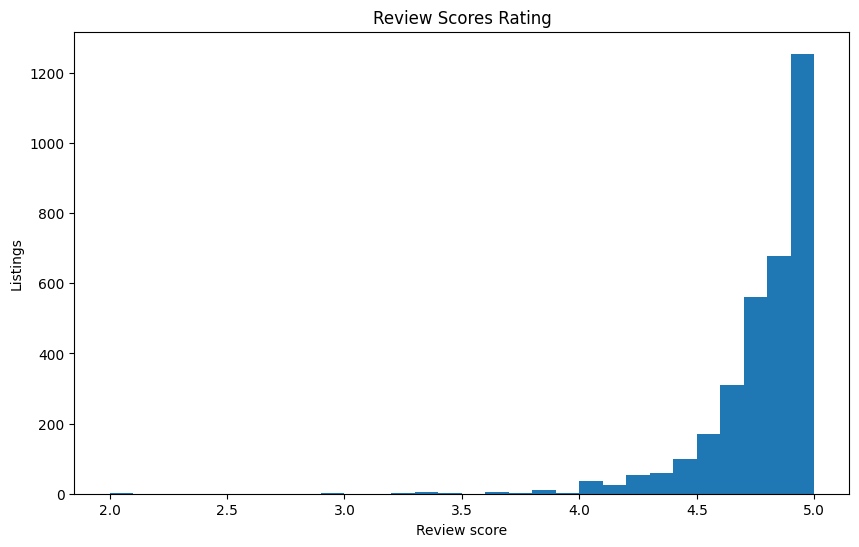

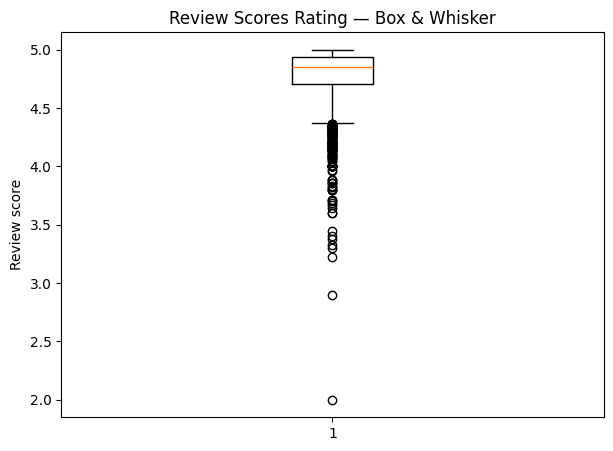

,host_id,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,availability_30,availability_365,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
count,"3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,162.000","3,251.000","3,160.000","3,155.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000","3,274.000"
mean,"222,200,025.636",53.149,32.810,-96.794,5.134,1.629,1.922,2.456,210.698,12.444,217.110,61.063,4.786,4.825,4.778,4.852,4.878,4.731,4.746,2.376
std,"182,803,838.788",296.086,0.062,0.048,3.470,0.886,1.252,2.232,559.557,10.247,118.277,88.733,0.233,0.202,0.232,0.204,0.188,0.276,0.236,2.088
min,"43,422.000",1.000,32.634,-96.988,1.000,0.000,0.000,0.000,10.000,0.000,0.000,5.000,2.000,3.300,3.290,2.400,2.400,3.000,1.600,0.050
25%,"47,055,693.000",2.000,32.778,-96.824,2.000,1.000,1.000,1.000,89.000,0.000,121.000,13.000,4.710,4.770,4.680,4.800,4.840,4.620,4.670,0.780
50%,"175,154,357.500",7.000,32.802,-96.794,4.000,1.000,1.000,2.000,130.000,13.000,240.000,30.000,4.850,4.880,4.840,4.920,4.940,4.820,4.800,1.920
75%,"406,729,399.000",26.000,32.823,-96.770,6.000,2.000,3.000,3.000,215.500,21.000,327.750,71.000,4.940,4.960,4.940,4.980,5.000,4.930,4.900,3.300
max,"578,705,651.000","7,928.000",33.012,-96.481,16.000,8.000,8.000,22.000,"10,000.000",30.000,365.000,"1,207.000",5.000,5.000,5.000,5.000,5.000,5.000,5.000,18.040


In [46]:
plt.figure(figsize=(10, 6))
plt.hist(listingsDF["review_scores_rating"].dropna(), bins=30)
plt.title("Review Scores Rating")
plt.xlabel("Review score")
plt.ylabel("Listings")
plt.show()

plt.figure(figsize=(7, 5))
plt.boxplot(listingsDF["review_scores_rating"].dropna())
plt.title("Review Scores Rating — Box & Whisker")
plt.ylabel("Review score")
plt.show()

display(listingsDF.describe())

In [47]:
GOOD_RATING_CUTOFF = 4.94
BAD_RATING_CUTOFF = 4.50

goodCount = (listingsDF["review_scores_rating"] >= GOOD_RATING_CUTOFF).sum()
badCount = (listingsDF["review_scores_rating"] <= BAD_RATING_CUTOFF).sum()
print("High-rated listings:", goodCount)
print("Low-rated listings:", badCount)

goodListingsDF = listingsDF[listingsDF["review_scores_rating"] >= GOOD_RATING_CUTOFF].copy()
badListingsDF = listingsDF[listingsDF["review_scores_rating"] <= BAD_RATING_CUTOFF].copy()

allListingsDF["listing_segment"] = np.select(
    [
        allListingsDF["review_scores_rating"] >= GOOD_RATING_CUTOFF,
        allListingsDF["review_scores_rating"] <= BAD_RATING_CUTOFF,
    ],
    ["high_rated_listing", "low_rated_listing"],
    default="middle_rated_listing",
)
listingsDF["listing_segment"] = listingsDF["id"].map(
    allListingsDF.set_index("id")["listing_segment"]
)

goodListingsDF.to_csv("goodListings.csv", index=False)
badListingsDF.to_csv("badListings.csv", index=False)
display(goodListingsDF.head())
display(badListingsDF.head())

High-rated listings: 885
Low-rated listings: 341


,id,listing_url,name,description,host_id,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_neighbourhood,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,availability_30,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
10,1826550,https://www.airbnb.com/rooms/1826550,Private Room in Canton Townhouse,"Comfortable and private guest room with a queen size bed, desk, couch, TV, attached bathroom and more, located all b...",9557710,Jeff,10/21/13,within an hour,100%,97%,Downtown,5,District 14,32.781,-96.792,Private room in townhouse,Private room,3,1.000,1 private bath,1.000,1.000,"[""Patio or balcony"", ""Board games"", ""Essentials"", ""Smoke alarm"", ""Self check-in"", ""Heating"", ""Rice maker"", ""Dishwash...",79.000,0,28,636,11/21/13,5/15/24,4.940,4.970,4.970,4.970,4.980,4.900,4.920,4.940
11,1832427,https://www.airbnb.com/rooms/1832427,Beautiful 3BR Canton Townhouse,This beautiful 3 story townhouse with downtown views is the ideal stop for both business and leisure travelers. Come...,9557710,Jeff,10/21/13,within an hour,100%,97%,Downtown,5,District 2,32.778,-96.794,Entire townhouse,Entire home/apt,8,3.500,3.5 baths,3.000,3.000,"[""Board games"", ""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""Self check-in"", ""Pantene conditioner"", ""Heat...",410.000,10,114,175,2/17/14,6/3/24,4.990,4.990,4.940,4.980,5.000,4.950,4.970,1.390
24,3143997,https://www.airbnb.com/rooms/3143997,Queen Size Suite Mid Town Dallas Private Home,Easy access to all DFW. One room with queen sized bed and attached private bathroom. Quiet Mid Town/Preston Hollow ...,15962199,Teena,5/25/14,within a few hours,100%,95%,Northwest Dallas,1,District 13,32.925,-96.827,Private room in home,Private room,1,1.000,1 private bath,1.000,1.000,"[""Patio or balcony"", ""Essentials"", ""Smoke alarm"", ""Private entrance"", ""Self check-in"", ""Heating"", ""Shampoo"", ""Bed li...",55.000,15,59,81,3/18/17,5/19/24,4.950,4.940,4.910,4.990,4.990,4.960,4.960,0.920
25,3199397,https://www.airbnb.com/rooms/3199397,European Touch near White Rock Lake,"This host provides a charming room and beautiful areas to sit outside and enjoy the garden. I will provide Coffee,T...",16213597,Alicia,5/31/14,NaN,NaN,NaN,Forest Hills/Casa Linda,1,District 9,32.819,-96.710,Private room in home,Private room,2,1.000,1 bath,1.000,1.000,"[""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""Heating"", ""Shampoo"", ""Dedicated workspace"", ""Dryer"", ""Carbo...",65.000,0,1,36,6/24/14,6/4/18,4.940,4.890,4.970,5.000,5.000,4.970,4.970,0.300
35,4833160,https://www.airbnb.com/rooms/4833160,East Uptown Townhome w/ City View,Renting the newly remodeled guest bed/movie room on 1st floor in a modern 3-story townhome east of Uptown and just n...,9649521,Cory,10/26/13,within an hour,100%,97%,Central Dallas,1,District 14,32.801,-96.786,Private room in townhouse,Private room,1,1.500,1.5 baths,1.000,1.000,"[""Board games"", ""Essentials"", ""City skyline view"", ""Smoke alarm"", ""Self check-in"", ""Rice maker"", ""Dishwasher"", ""Sun ...",68.000,0,89,321,1/12/15,2/29/24,4.980,4.980,4.980,4.970,4.990,4.950,4.950,2.790


,id,listing_url,name,description,host_id,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_neighbourhood,host_total_listings_count,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,availability_30,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
16,2707172,https://www.airbnb.com/rooms/2707172,"Queen, Walk in Shower-TV-- Internet","Spacious upstairs bedroom. Private bath, breakfast, tea and coffee. Upstairs lounge/office with 55"" wall mount TV....",12321313,Judith,2/17/14,within a few hours,100%,50%,Bent Tree,3,District 12,32.993,-96.837,Private room in home,Private room,2,1.000,1 private bath,1.000,1.000,"[""Free parking on premises"", ""Backyard"", ""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""First aid kit"", ""Wa...",78.000,30,365,16,7/17/15,11/17/23,4.500,4.560,4.750,4.530,4.380,4.530,4.330,0.150
42,6488857,https://www.airbnb.com/rooms/6488857,King Bed Spa Bath Minutes From Downtown Dallas,"Stay at this spacious, newly renovated home. While located only minutes from Dallas’ medical centers, White Rock Lak...",32135472,Jamal,4/28/15,a few days or more,0%,0%,NaN,1,District 9,32.844,-96.673,Entire home,Entire home/apt,8,3.000,3 baths,4.000,4.000,"[""42 inch HDTV with Amazon Prime Video, Roku"", ""Essentials"", ""Smoke alarm"", ""Self check-in"", ""Heating"", ""Dishwasher""...",185.000,26,175,5,10/2/22,7/6/23,3.600,4.200,3.800,4.200,4.000,4.400,3.800,0.240
162,17478348,https://www.airbnb.com/rooms/17478348,North Dallas Quiet Condo,Well-located unit near the Galleria and Addison. Top floor end-unit is quiet with high ceilings. Nice patio to enjo...,107583316,Anthony,12/17/16,within a few hours,100%,100%,North Central Dallas,3,District 11,32.940,-96.812,Entire condo,Entire home/apt,3,1.000,1 bath,1.000,1.000,"[""Essentials"", ""Smoke alarm"", ""Generic body soap"", ""Private entrance"", ""Self check-in"", ""Heating"", ""Dishwasher"", ""Sh...",71.000,0,126,22,5/7/17,4/5/24,4.410,4.640,4.000,4.950,4.950,4.680,4.410,0.250
168,17669809,https://www.airbnb.com/rooms/17669809,⭐️⭐️A Premier Location Heart of Victory Park⭐️⭐️,We used to have apartments in this location it didn't fit our needs anymore. So we transfer to an amazing location P...,108514926,Dalls,12/26/16,within an hour,92%,95%,Oak Lawn,463,District 2,32.792,-96.809,Entire rental unit,Entire home/apt,4,1.000,1 bath,1.000,2.000,"[""Patio or balcony"", ""Host greets you"", ""Essentials"", ""Smoke alarm"", ""TV with standard cable"", ""Private entrance"", ""...",120.000,0,108,8,3/16/17,4/3/22,4.500,5.000,4.880,4.500,4.500,5.000,5.000,0.090
180,18026976,https://www.airbnb.com/rooms/18026976,⭐️⭐️ AMAZING PRICE West-Village Walk Anywhere ⭐️⭐️,We used to have apartments in this building we move them to a newer building next to it please look online for <br /...,108514926,Dalls,12/26/16,within an hour,92%,95%,Oak Lawn,463,District 14,32.809,-96.796,Entire rental unit,Entire home/apt,2,1.000,1 bath,1.000,1.000,"[""Host greets you"", ""Essentials"", ""Smoke alarm"", ""Private entrance"", ""50 inch HDTV with Amazon Prime Video, Fire TV,...",120.000,0,267,8,11/27/17,8/16/22,4.250,4.130,4.500,4.250,4.380,4.880,4.250,0.100


In [48]:
reviewsDF = pd.read_excel("reviewsfinal.xlsx", dtype={"listing_id": "string"})
reviewsDF = reviewsDF.rename(columns={"date1": "date"})
reviewsDF["listing_id"] = reviewsDF["listing_id"].str.strip()
reviewsDF["review_row_id"] = "R_" + reviewsDF.index.astype("string")

print("The number of reviews are:", len(reviewsDF))
print("Reviews with missing comments:", reviewsDF["comments"].isna().sum())
display(reviewsDF.head())

The number of reviews are: 201901
Reviews with missing comments: 80


,listing_id,date,reviewer_id,reviewer_name,comments,review_row_id
0,61878,2010-12-29,94938,Genevieve,"Rita's condo was a great fit for our party of 3. My brother slept on the fold out couch, and my boyfriend and I stay...",R_0
1,10042361,2016-06-02,23759635,Shelbi,The listed was as described and the area many restaurants within walking distance. I needed Brett to fix the garbage...,R_1
2,10042361,2016-12-15,2822452,Sarah,Brett was a very helpful host. He answered questions and fixed things quickly. The studio is in a great neighborhood...,R_2
3,10042361,2017-02-11,101152628,Archit,This place is great for staying long term . It has all the furniture you need and Brett is always there to help. He'...,R_3
4,10042361,2017-07-01,125738908,Andrew,The apartment was exactly as advertised and Brett was very accommodating and easy to communicate with.,R_4


In [49]:
def clean_review(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)
    text = re.sub(r"<[^>]*>", " ", text)
    text = re.sub(r"n['’]t\b", " not", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

reviewsDF["cleanComments"] = reviewsDF["comments"].map(clean_review)
reviewsDF["hasText"] = reviewsDF["cleanComments"].ne("")
display(reviewsDF[["comments", "cleanComments"]].head())

,comments,cleanComments
0,"Rita's condo was a great fit for our party of 3. My brother slept on the fold out couch, and my boyfriend and I stay...",rita s condo was a great fit for our party of my brother slept on the fold out couch and my boyfriend and i stayed i...
1,The listed was as described and the area many restaurants within walking distance. I needed Brett to fix the garbage...,the listed was as described and the area many restaurants within walking distance i needed brett to fix the garbage ...
2,Brett was a very helpful host. He answered questions and fixed things quickly. The studio is in a great neighborhood...,brett was a very helpful host he answered questions and fixed things quickly the studio is in a great neighborhood v...
3,This place is great for staying long term . It has all the furniture you need and Brett is always there to help. He'...,this place is great for staying long term it has all the furniture you need and brett is always there to help he s c...
4,The apartment was exactly as advertised and Brett was very accommodating and easy to communicate with.,the apartment was exactly as advertised and brett was very accommodating and easy to communicate with


In [50]:
goodReviewsDF = reviewsDF[reviewsDF["listing_id"].isin(goodListingsDF["id"])].copy()
badReviewsDF = reviewsDF[reviewsDF["listing_id"].isin(badListingsDF["id"])].copy()

print("Reviews of high-rated listings:", len(goodReviewsDF))
print("Reviews of low-rated listings:", len(badReviewsDF))
display(goodReviewsDF.head())
display(badReviewsDF.head())

Reviews of high-rated listings: 52267
Reviews of low-rated listings: 10096


,listing_id,date,reviewer_id,reviewer_name,comments,review_row_id,cleanComments,hasText
559,16239694,2017-04-30,11326415,Sermons,"Tom and Diane's home was simply incredible. From the amazing linens, ambiance, furnishings, and location, this is tr...",R_559,tom and diane s home was simply incredible from the amazing linens ambiance furnishings and location this is truly a...,True
560,16239694,2017-05-21,107468300,Pamela,This is my first entry into AirBNB and it will be hard to live up to. This beautifully appointed home is located in ...,R_560,this is my first entry into airbnb and it will be hard to live up to this beautifully appointed home is located in a...,True
562,16239694,2017-06-08,67100006,Rakan,"Beautiful house, we had a wonderful stay. Our hosts were very quick to respond to any requests and went out of their...",R_562,beautiful house we had a wonderful stay our hosts were very quick to respond to any requests and went out of their w...,True
563,16239694,2017-09-04,57125780,Jana,"Tom and Margaret, the property manager, were wonderful hosts. Thank you for a great trip.",R_563,tom and margaret the property manager were wonderful hosts thank you for a great trip,True
596,16239694,2017-09-28,27011045,Guirchaume,"Beautiful House, nice host. I highly recommend this house...",R_596,beautiful house nice host i highly recommend this house,True


,listing_id,date,reviewer_id,reviewer_name,comments,review_row_id,cleanComments,hasText
4920,2707172,2015-07-17,35921231,Christopher,Judith is a very pleasant and nice person to be staying with. She is incredibly friendly and very very accommodating...,R_4920,judith is a very pleasant and nice person to be staying with she is incredibly friendly and very very accommodating ...,True
4957,2707172,2015-09-12,40015910,Steven,I was visiting Dallas for training at American Flyers. The location for me was perfect. I needed a place to stay t...,R_4957,i was visiting dallas for training at american flyers the location for me was perfect i needed a place to stay that ...,True
4993,2707172,2016-05-27,836615,Shelley,Judith is an exceptionally gracious host who goes above and beyond to provide for her guests and she has a beautiful...,R_4993,judith is an exceptionally gracious host who goes above and beyond to provide for her guests and she has a beautiful...,True
4994,2707172,2017-02-03,93271380,Gary,Wonderful home in a very nice upscale neighborhood. Judith was very helpful with my check-in and making sure I was ...,R_4994,wonderful home in a very nice upscale neighborhood judith was very helpful with my check in and making sure i was co...,True
4995,2707172,2017-03-21,93271380,Gary,Always a pleasant experience at Judith's. Quiet and comfortable. Close to everything and parking there is easy nex...,R_4995,always a pleasant experience at judith s quiet and comfortable close to everything and parking there is easy next to...,True


In [51]:
try:
    positiveWords = set(opinion_lexicon.positive())
    negativeWords = set(opinion_lexicon.negative())
except LookupError:
    nltk.download("opinion_lexicon", quiet=True)
    positiveWords = set(opinion_lexicon.positive())
    negativeWords = set(opinion_lexicon.negative())

def count_words(text, wordSet):
    return sum(word in wordSet for word in text.split())

reviewsDF["positiveWordCount"] = reviewsDF["cleanComments"].map(
    lambda text: count_words(text, positiveWords)
)
reviewsDF["negativeWordCount"] = reviewsDF["cleanComments"].map(
    lambda text: count_words(text, negativeWords)
)
reviewsDF["sentimentWordTotal"] = reviewsDF["positiveWordCount"] + reviewsDF["negativeWordCount"]
reviewsDF["sentimentScore"] = np.where(
    reviewsDF["sentimentWordTotal"] > 0,
    (reviewsDF["positiveWordCount"] - reviewsDF["negativeWordCount"])
    / reviewsDF["sentimentWordTotal"],
    0,
)
reviewsDF["sentimentLabel"] = np.select(
    [
        ~reviewsDF["hasText"],
        reviewsDF["negativeWordCount"] > reviewsDF["positiveWordCount"],
        reviewsDF["positiveWordCount"] > reviewsDF["negativeWordCount"],
    ],
    ["no_text", "negative", "positive"],
    default="neutral",
)

goodReviewsDF = reviewsDF[reviewsDF["listing_id"].isin(goodListingsDF["id"])].copy()
badReviewsDF = reviewsDF[reviewsDF["listing_id"].isin(badListingsDF["id"])].copy()
display(reviewsDF["sentimentLabel"].value_counts())

sentimentLabel
positive    189630
neutral       7676
negative      3608
no_text        987
Name: count, dtype: int64

In [52]:
allGoodWords = []
for text in goodReviewsDF["cleanComments"].fillna("").astype(str):
    allGoodWords.extend([word for word in text.split() if word in positiveWords])

top30GoodWords = Counter(allGoodWords).most_common(30)
top30GoodWords

[('great', 28771),
 ('clean', 13521),
 ('comfortable', 9301),
 ('recommend', 8973),
 ('perfect', 8894),
 ('nice', 8202),
 ('beautiful', 7561),
 ('amazing', 6556),
 ('well', 6384),
 ('loved', 6274),
 ('super', 6187),
 ('easy', 5263),
 ('responsive', 4858),
 ('wonderful', 4805),
 ('like', 4475),
 ('enjoyed', 4258),
 ('quiet', 4090),
 ('cozy', 3854),
 ('helpful', 3221),
 ('good', 3148),
 ('best', 3037),
 ('cute', 2926),
 ('friendly', 2887),
 ('thank', 2805),
 ('lovely', 2724),
 ('safe', 2514),
 ('love', 2496),
 ('awesome', 2442),
 ('spacious', 2352),
 ('excellent', 2204)]

In [53]:
allBadWords = []
for text in badReviewsDF["cleanComments"].fillna("").astype(str):
    allBadWords.extend([word for word in text.split() if word in negativeWords])

top30BadWords = Counter(allBadWords).most_common(30)
top30BadWords

[('issues', 384),
 ('dirty', 354),
 ('issue', 338),
 ('broken', 246),
 ('noise', 233),
 ('smell', 231),
 ('bad', 219),
 ('loud', 209),
 ('trash', 178),
 ('problem', 160),
 ('hard', 153),
 ('stains', 141),
 ('noisy', 123),
 ('smelled', 116),
 ('difficult', 113),
 ('complex', 103),
 ('cold', 102),
 ('uncomfortable', 98),
 ('horrible', 91),
 ('unfortunately', 90),
 ('sink', 86),
 ('terrible', 86),
 ('problems', 83),
 ('worst', 82),
 ('confusing', 75),
 ('cheap', 74),
 ('disappointed', 73),
 ('complaint', 72),
 ('bugs', 71),
 ('cons', 71)]

Good TF-IDF shape: (52267, 34004)


,word,meanTfidf
13061,great,0.041
28321,stay,0.035
22864,place,0.034
17740,location,0.020
5146,clean,0.020
14634,host,0.019
14127,home,0.018
33744,would,0.018
15077,house,0.016
20569,nice,0.016


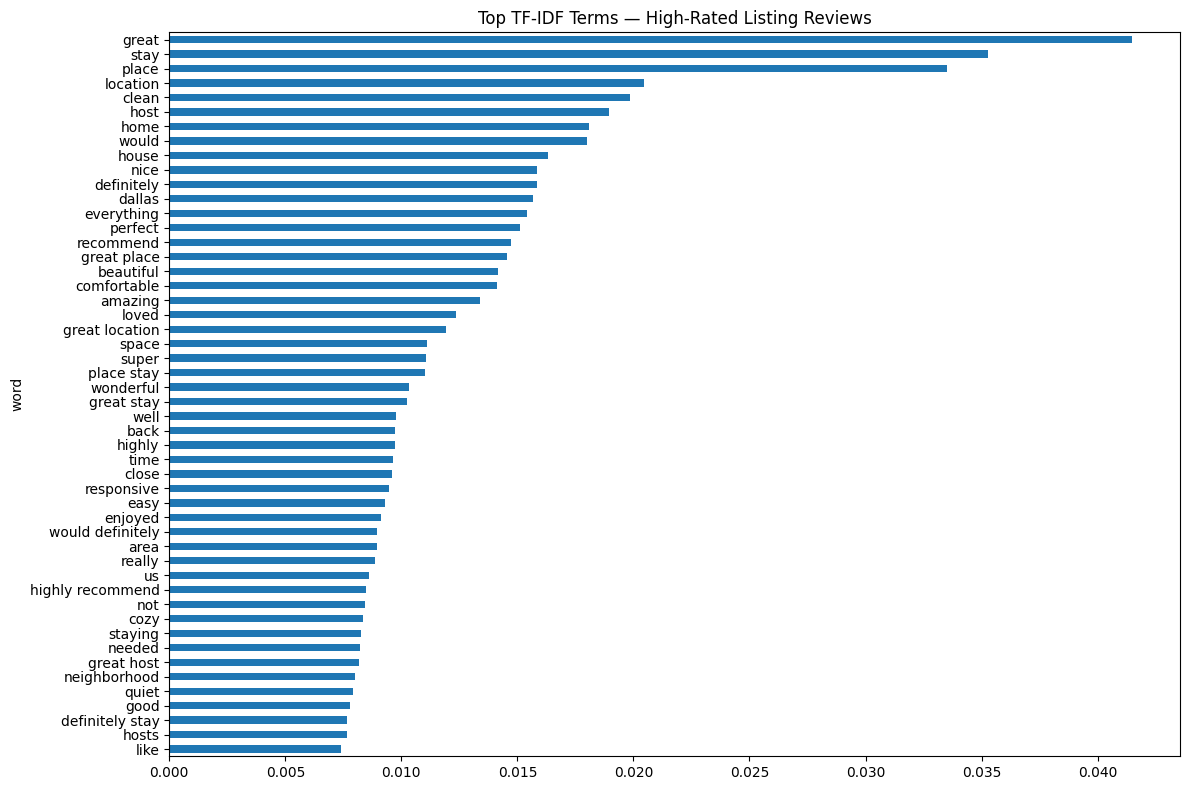

In [54]:
stopWords = set(stopwords.words("english"))
for word in ["not", "no", "nor", "never"]:
    stopWords.discard(word)

vectorizer = TfidfVectorizer(
    stop_words=list(stopWords),
    ngram_range=(1, 2),
    min_df=5,
)
XGoodTfidf = vectorizer.fit_transform(goodReviewsDF["cleanComments"].fillna(""))
featureNames = vectorizer.get_feature_names_out()
goodMeanTfidf = np.asarray(XGoodTfidf.mean(axis=0)).ravel()

goodTfidfDF = pd.DataFrame({
    "word": featureNames,
    "meanTfidf": goodMeanTfidf,
}).sort_values("meanTfidf", ascending=False)

top50Good = goodTfidfDF.head(50)
print("Good TF-IDF shape:", XGoodTfidf.shape)
display(top50Good.head(20))

top50Good.sort_values("meanTfidf").plot.barh(
    x="word", y="meanTfidf", figsize=(12, 8), legend=False,
    title="Top TF-IDF Terms — High-Rated Listing Reviews",
)
plt.tight_layout()
plt.show()

In [55]:
isBigram = np.array([" " in term for term in featureNames])
goodMeanTfidf = XGoodTfidf.mean(axis=0).A1

goodBigramDF = pd.DataFrame({
    "bigram": featureNames[isBigram],
    "meanTfidf": goodMeanTfidf[isBigram],
})

top30GoodBigrams = goodBigramDF.sort_values(
    "meanTfidf", ascending=False
).head(30)

top30GoodBigrams

,bigram,meanTfidf
10866,great place,0.015
10809,great location,0.012
19121,place stay,0.011
10936,great stay,0.010
27597,would definitely,0.009
11444,highly recommend,0.008
10773,great host,0.008
6650,definitely stay,0.008
7782,enjoyed stay,0.006
18910,place great,0.005


In [56]:
reviewsEnrichedDF = reviewsDF.merge(
    allListingsDF[["id", "listing_segment"]].rename(columns={"id": "listing_id"}),
    on="listing_id",
    how="left",
    validate="many_to_one",
)

termRows = []
for listingSegment, segmentDF in reviewsEnrichedDF.groupby("listing_segment"):
    for sentiment, wordSet in [("positive", positiveWords), ("negative", negativeWords)]:
        wordCounts = Counter()
        for text in segmentDF.loc[segmentDF["hasText"], "cleanComments"]:
            wordCounts.update(word for word in text.split() if word in wordSet)
        for rank, (term, count) in enumerate(wordCounts.most_common(50), start=1):
            termRows.append({
                "listing_segment": listingSegment,
                "sentiment": sentiment,
                "term": term,
                "count": count,
                "rank": rank,
            })

tableauTermCountsDF = pd.DataFrame(termRows)
display(tableauTermCountsDF.head(20))

,listing_segment,sentiment,term,count,rank
0,high_rated_listing,positive,great,29452,1
1,high_rated_listing,positive,clean,13797,2
2,high_rated_listing,positive,comfortable,9452,3
3,high_rated_listing,positive,recommend,9187,4
4,high_rated_listing,positive,perfect,9019,5
5,high_rated_listing,positive,nice,8412,6
6,high_rated_listing,positive,beautiful,7693,7
7,high_rated_listing,positive,amazing,6666,8
8,high_rated_listing,positive,well,6496,9
9,high_rated_listing,positive,loved,6376,10


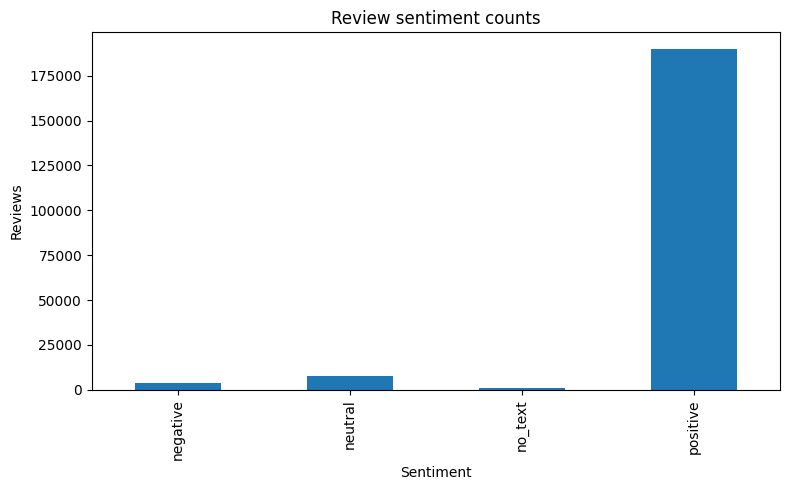

In [57]:
sentimentCounts = pd.crosstab(reviewsDF["sentimentLabel"], columns="reviews")
sentimentCounts.plot.bar(figsize=(8, 5), legend=False, title="Review sentiment counts")
plt.xlabel("Sentiment")
plt.ylabel("Reviews")
plt.tight_layout()
plt.show()

In [58]:
positiveDF = pd.DataFrame(top30GoodWords, columns=["positiveWords", "positiveNum"])
negativeDF = pd.DataFrame(top30BadWords, columns=["negativeWords", "negativeNum"])
wordCountsDF = pd.concat([positiveDF, negativeDF], axis=1)
wordCountsDF.to_csv("word_counts.csv", index=False)
display(wordCountsDF.head())
tableauTermCountsDF.to_csv("tableau_term_counts.csv", index=False)

,positiveWords,positiveNum,negativeWords,negativeNum
0,great,28771,issues,384
1,clean,13521,dirty,354
2,comfortable,9301,issue,338
3,recommend,8973,broken,246
4,perfect,8894,noise,233


In [59]:
tableauListingsDF = allListingsDF.copy()
tableauReviewsDF = reviewsEnrichedDF.copy()

tableauListingsDF.to_csv("tableau_listings.csv", index=False)
tableauReviewsDF.to_csv("tableau_reviews.csv", index=False)
goodReviewsDF.to_csv("goodReviewsDF.csv", index=False)
badReviewsDF.to_csv("badReviewsDF.csv", index=False)

In [60]:
tableauKpisDF = pd.DataFrame([
    ["listings", len(listingsDF)],
    ["high_rated_listings", len(goodListingsDF)],
    ["low_rated_listings", len(badListingsDF)],
    ["review_rows", len(reviewsDF)],
    ["reviews_with_text", int(reviewsDF["hasText"].sum())],
    ["positive_reviews", int((reviewsDF["sentimentLabel"] == "positive").sum())],
    ["neutral_reviews", int((reviewsDF["sentimentLabel"] == "neutral").sum())],
    ["negative_reviews", int((reviewsDF["sentimentLabel"] == "negative").sum())],
    ["highest_listing_review_count", listingsDF["number_of_reviews"].max()],
    ["average_listing_rating", listingsDF["review_scores_rating"].mean()],
    ["average_price", listingsDF["price"].mean()],
    ["median_price", listingsDF["price"].median()],
    ["total_stated_reviews", int(listingsDF["number_of_reviews"].sum())],
])
tableauKpisDF.columns = ["kpi", "value"]
tableauKpisDF.to_csv("tableau_kpis.csv", index=False)
display(tableauKpisDF)
print("Unmatched review rows:", reviewsDF["listing_id"].isin(allListingsDF["id"]).eq(False).sum())
print("Reviews exported:", len(tableauReviewsDF))
print("All checks complete.")

,kpi,value
0,listings,"3,274.000"
1,high_rated_listings,885.000
2,low_rated_listings,341.000
3,review_rows,"201,901.000"
4,reviews_with_text,"200,914.000"
5,positive_reviews,"189,630.000"
6,neutral_reviews,"7,676.000"
7,negative_reviews,"3,608.000"
8,highest_listing_review_count,"1,207.000"
9,average_listing_rating,4.786


Unmatched review rows: 0
Reviews exported: 201901
All checks complete.
